In [1]:
what_were_covering = {
    1: "data (prepare and load)",
    2: "build model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating the model",
    5: "saving and loading the model",
    6: "putting it all together (end-to-end example)"
}
what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating the model',
 5: 'saving and loading the model',
 6: 'putting it all together (end-to-end example)'}

In [2]:
import torch
from torch import nn ## nn contains all of the modules, classes, functions etc. needed to build neural networks
import matplotlib.pyplot as plt

torch.__version__

'2.7.1+cpu'

In [3]:
weight = 0.3
bias = 0.7

#create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1) # unsqueeze adds a dimension to the tensor
y = weight * X + bias

In [4]:
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.7000],
         [0.7060],
         [0.7120],
         [0.7180],
         [0.7240],
         [0.7300],
         [0.7360],
         [0.7420],
         [0.7480],
         [0.7540]]))

In [5]:
X.shape

torch.Size([50, 1])

In [6]:
train_split = int(0.8 * len(X))
train_split

40

In [7]:
X_train, y_train = X[:train_split], y[:train_split]

In [8]:
X_test, y_test = X[train_split:], y[train_split:]

In [9]:
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

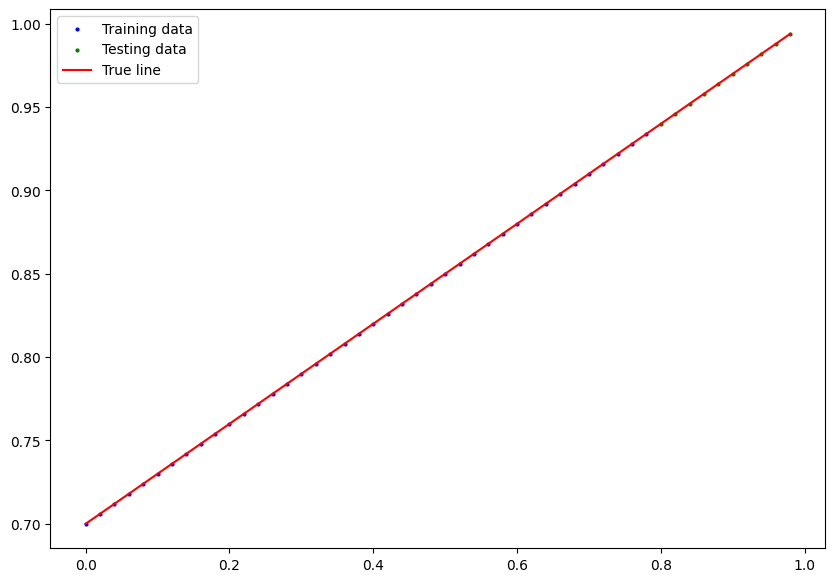

In [10]:
plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")
plt.scatter(X_test, y_test, c="g", s=4, label="Testing data")
plt.plot(X, weight * X + bias, c="r", label="True line")
plt.legend()

In [11]:
names = ['Ala', 'Bartek']
scores = [5, 4]

# Pythonic
for name, score in zip(names, scores):
    print(f"{name} has score {score}")


Ala has score 5
Bartek has score 4


In [12]:
lista = [n for n in range(10) if n % 2 == 0]
lista

[0, 2, 4, 6, 8]

In [13]:
words = ['cat', 'dog', 'cat', 'bird']
from collections import Counter
counts = Counter(words)
counts

Counter({'cat': 2, 'dog': 1, 'bird': 1})

In [14]:
words.count('cat')

2

In [15]:
files = ['a.txt', 'b.csv', 'notes.txt', 'README.md']
txt_files = [f for f in files if f.endswith('.txt')]
txt_files

['a.txt', 'notes.txt']

In [16]:
files = ['a.txt', 'b.csv', 'notes.txt', 'README.md']
title = ['1', '2', '3', '4','5']

In [17]:
for file, titles in zip(files, title):
    print(f"File: {file}, Title: {titles}")

File: a.txt, Title: 1
File: b.csv, Title: 2
File: notes.txt, Title: 3
File: README.md, Title: 4


What model does:
* start with random values (weight and bias)
* look at traning data and adjust the random values to better represent (or get closer to) the ideal values (the weights and bias vaqlues we used to create the data)

How does it do so?
Through two main algorithms
1. Gredient descent https://www.youtube.com/watch?v=IHZwWFHWa-w
2. Backpropagation https://www.youtube.com/watch?v=Ilg3gGewQ5U

In [18]:
from torch import nn

class LinearRegressionModel(nn.Module): 
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(
            torch.randn(1,
                        requires_grad=True,
                        dtype=torch.float)
        )
        self.bias = nn.Parameter(
            torch.randn(1,
                        requires_grad=True,
                        dtype=torch.float)
        )

        #forward method to define the computation in the model

    def forward(self, x:torch.Tensor) -> torch.Tensor: # x<- is the input data
        return self.weights * x + self.bias

### PyTorch model building essentials

* torch.nn - contains all of the building for computional graphs (another word for neural networks)
* torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us
* torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward()
* torch.optim - this where the optimizers in pytorch live, they will help with gradient descent
* def forward() - All nn.Module subclasses require to overwrite forward(), this method defines what happens in the forward computation

### Checking the contents of our PyTorch model

Now we've created a model, let's see what's inside... 

So we can check our model parameters or whats inside our model using .parameters()

In [21]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [28]:
torch.manual_seed(42)
torch.randn(1), torch.randn(1)

(tensor([0.3367]), tensor([0.1288]))

In [29]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [30]:
weight, bias

(0.3, 0.7)

### Making prediction using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts 'y_test' based on 'X_test'.

When we pass data through our model, it's godzin to run it through the `forward()` method.

In [54]:
y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [60]:
# Make predictions with model - torch.inference_mode() moze sprawaiac ze predykcje beda szybsze - do doczytania ocb

with torch.inference_mode():
    y_preds = model_0(X_test)

# You can also do somethhing similar torch.no_grad(), however torch.inference_mode() is preffered
# with torch.no_grad():
#     y_preds = model_0(X_test)


y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

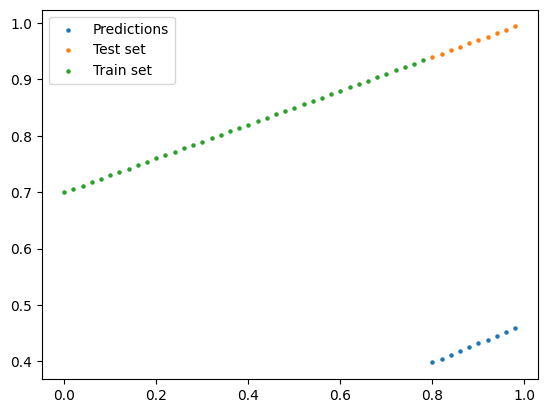

In [63]:
plt.scatter(x = X_test, y = y_preds, s = 5, label = 'Predictions')
plt.scatter(x = X_test, y = y_test, s = 5, label = 'Test set')
plt.scatter(x = X_train, y = y_train, s = 5, label = 'Train set')
plt.legend()

In [66]:
(((y_test - y_preds)*2).sum())/len(y_test) # MSE

tensor(1.0771)

In [65]:
(((y_test - y_preds)*2).sum()/len(y_test)).sqrt() # RMSE

tensor(1.0378)

In [67]:
((y_test - y_preds).abs().sum())/len(y_test) # MAE

tensor(0.5385)

## 3. Train model

The whole idea of training is for a model to move from some *unknown* parameters (these may be random) to some *known* parameters,

Or in other words from a poor representation of the data to a better representation of a data.

One way to measure how poor or how worng your models predictions are is to use a loss function.

* Note: Loss function may also be called cost funtion or criterion in defferent areas. For our case, we're going to refer to it as a loss function

Things we need to train:

* **Loss function:** A function to measure how wrong your model's predctioions are to the ideal outputs. Lower is better.

* **Optimizer:** Takes into account the loss of a model and adjust the model's parameters (e.g. weight and bias in our case) to impore the loss function

And a specifically for pytorch, we need:
* a training loop
* a testing loop

In [69]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [70]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])